In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Lab_Exam_binary_classification_dataset.csv")

print(f'Shape -> {df.shape}')

df.head()

Shape -> (1020, 3)


,Feature1,Feature2,Target
0,1.7250,520,Yes
1,1.8875,428,No
2,1.6000,552,Yes
3,1.4250,500,No
4,1.7750,628,No


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  1020 non-null   float64
 1   Feature2  1020 non-null   int64  
 2   Target    1000 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 24.0+ KB


In [25]:
df.describe()

,Feature1,Feature2
count,1020.000000,1020.000000
mean,11.436679,520.988235
std,313.061049,69.793442
min,1.250000,400.000000
25%,1.450000,464.000000
50%,1.637500,520.000000
75%,1.828125,584.000000
max,10000.000000,640.000000


In [26]:
# Nulls
df.isna().sum()

Feature1     0
Feature2     0
Target      20
dtype: int64

In [27]:
# Clear n/a
if df.isna().sum().sum() != 0:
    df = df.dropna()

In [28]:
# Nulls
df.isna().sum()

Feature1    0
Feature2    0
Target      0
dtype: int64

In [29]:
df['Target'] = df['Target'].map({'Yes': 1, 'No': 0})

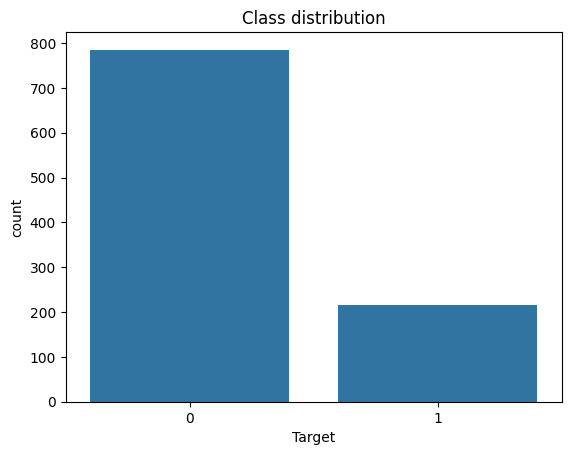

In [32]:
sns.countplot(x='Target', data=df)
plt.title("Class distribution")
plt.show()

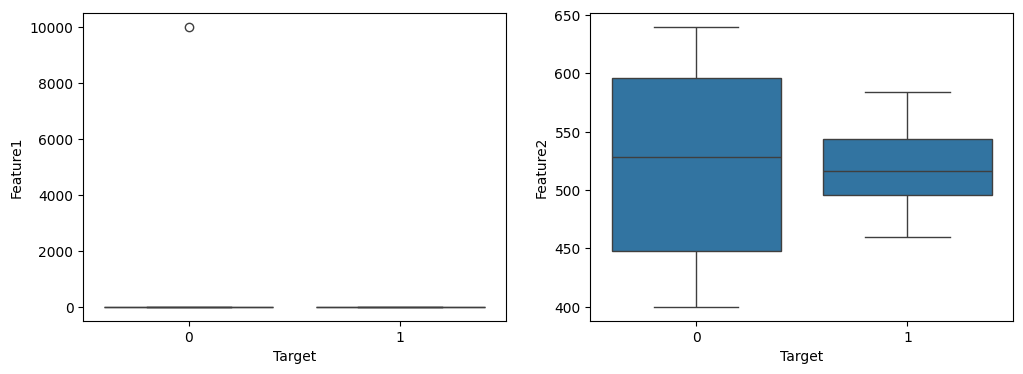

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='Target', y='Feature1', data=df, ax=axes[0])
sns.boxplot(x='Target', y='Feature2', data=df, ax=axes[1])
plt.show()

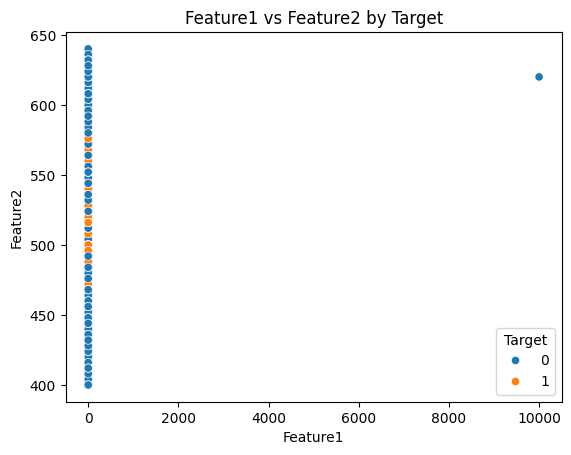

In [36]:
sns.scatterplot(x='Feature1', y='Feature2', hue='Target', data=df)
plt.title('Feature1 vs Feature2 by Target')
plt.show()

In [37]:
print(df['Feature1'].describe())
print(df['Feature1'].sort_values(ascending=False).head(10))

count     1000.000000
mean        11.632912
std        316.176154
min          1.250000
25%          1.450000
50%          1.637500
75%          1.837500
max      10000.000000
Name: Feature1, dtype: float64
132    10000.0
463        2.0
531        2.0
393        2.0
75         2.0
879        2.0
947        2.0
6          2.0
34         2.0
689        2.0
Name: Feature1, dtype: float64


In [40]:
# Data cleaning
Q1 = df['Feature1'].quantile(0.25)
Q3 = df['Feature1'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Feature1'] >= Q1 - 1.5 * IQR) & 
        (df['Feature1'] <= Q3 + 1.5 * IQR)]

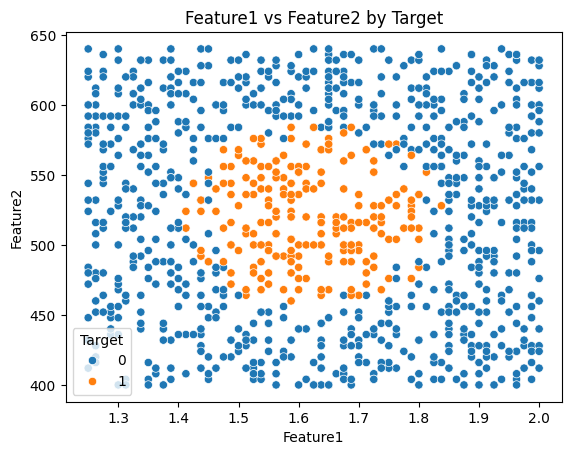

In [41]:
sns.scatterplot(x='Feature1', y='Feature2', hue='Target', data=df)
plt.title('Feature1 vs Feature2 by Target')
plt.show()